# Import modules

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy

import os 
import glob  
import pickle
import cmocean

import sys
sys.path.append('C:/Users/sebas/git/')

import icewave.sebastien.set_graphs as set_graphs
import icewave.tools.Fourier_tools as FT
import icewave.sebastien.theory.module_bilayer_viscous_dimensionless as theory
import icewave.tools.rw_data as rw

global g
g = 9.81

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif='Computer Modern')

full_blues = mpl.colormaps['Blues'].resampled(256)
new_blues = mcolors.ListedColormap(full_blues(np.linspace(0.2,1,256)))

## Function section

In [12]:

def affine(x,a,b):
    y = a*x + b
    return y

def powerlaw_fit(x,y,err_y = None):
    """ Fit data using a power law, taking into account standard deviation of y """
    log_x = np.log(x)
    log_y = np.log(y)
    
    if err_y is None :
        popt,pcov = scipy.optimize.curve_fit(lambda x,a,b : affine(log_x,a,b),log_x,log_y)
    
    else : 
        
        err_log_y = err_y/y
        popt,pcov = scipy.optimize.curve_fit(lambda x,a,b : affine(log_x,a,b),log_x,log_y,sigma = err_log_y,
                                             absolute_sigma = True)
        
    err_affine = np.sqrt(np.diag(pcov))
    beta = popt[0]
    err_beta = err_affine[0]
    B = np.exp(popt[1])
    err_B = B*err_affine[1]
    
    coeffs = (beta,B)
    err_coeffs = (err_beta,err_B)
    return coeffs,err_coeffs


In [7]:
# define fig_folder
fig_folder = 'F:/PhD_Manuscript/ch3/Attenuation/illustration/'
if not os.path.isdir(fig_folder) :
    os.mkdir(fig_folder)

In [ ]:
# load Aurore data
file2load = 'U:/Aurore_frasil/attenuation_results.pkl'
with open(file2load,'rb') as pf:
    data = pickle.load(pf)

## Plot data using Lamb model fit 

[-9.48077809]
[-9.27520276]
[-8.82966369]
[-8.2985148]
[-8.14612927]
[-7.98234534]


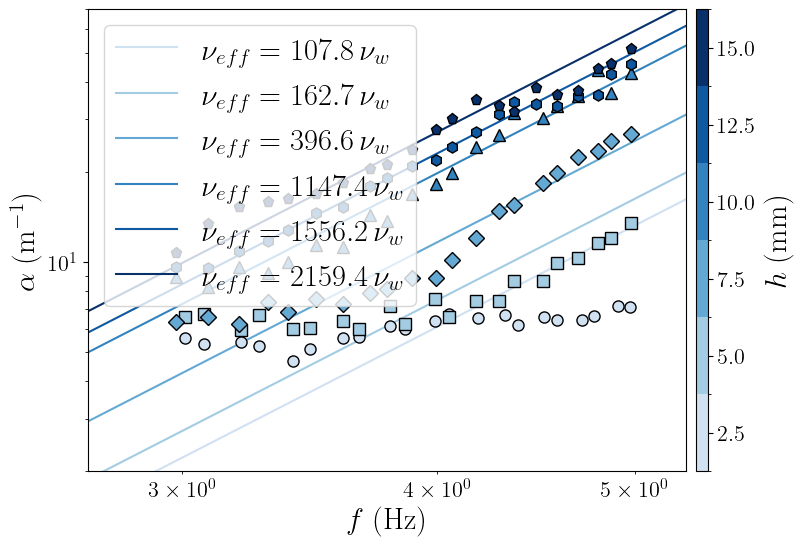

In [8]:
set_graphs.set_matplotlib_param('single')
method = 'laser'
thickness_list = [2.5,5.0,7.5,10.0,12.5,15.0]

bounds = np.array([1.25,3.75,6.25,8.75,11.25,13.75,16.25]) # bounds used for colorbar
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
cmap = new_blues
marker_list = ['o','s','D','^','h','p']
fig, ax = plt.subplots()

effective_table = {}
effective_table[method] = {'h':[],'nu':[],'prefactor':[],
                           'err_nu':[],'err_prefactor':[]}

for i,h in enumerate(thickness_list):

    valid_keys = []
    for key in data.keys():
        if data[key]['method'] == method and data[key]['h'] == h:
            valid_keys.append(key)
            
    alpha = np.array([data[key]['alpha'] for key in valid_keys])
    err_alpha = np.array([data[key]['err_alpha'] for key in valid_keys])
    f_demod = np.array([data[key]['f_demod'] for key in valid_keys])
    
    
    current_color = cmap(norm(h))
    marker = marker_list[i]
    ax.errorbar(f_demod,alpha,yerr = err_alpha,fmt = marker,color = current_color,markeredgecolor = 'k',ecolor = 'k',
                markersize = 8)
    
    xth = np.linspace(2.0,6.0,100)
    
    # power law fit 
    # coeffs,err_coeff = powerlaw_fit(f_demod, alpha, err_alpha)
    # yth = coeffs[1]*xth**coeffs[0]
    # label_th = r'$y = ' + f'{coeffs[1]:.2f}'+ 'f^{' + f'{coeffs[0]:.3f}' + '}$'
    # print(label_th)
    
    # fit by power law omega**3.5
    beta = 3.5
    popt,pcov = scipy.optimize.curve_fit(lambda x,b : affine(x, beta, b),np.log(f_demod*2*np.pi),np.log(alpha),
                                         sigma = err_alpha/alpha,absolute_sigma = True,
                                         bounds = (np.log(1e-5),np.log(1e-1)))
    print(popt)
    coeff = popt[0]
    err_coeff = np.sqrt(np.diag(pcov))[0]
    yth = np.exp(affine(np.log(xth*2*np.pi),beta,coeff))
    
    effective_table[method]['h'].append(h)
    effective_table[method]['prefactor'].append(np.exp(coeff))
    effective_table[method]['err_prefactor'].append(np.exp(coeff)*err_coeff)
    
    nu = 2*pow(np.exp(coeff),2)*pow(g,4)
    err_nu = 4*pow(g,4)*np.exp(coeff)*np.exp(coeff)*err_coeff
    effective_table[method]['nu'].append(nu)
    effective_table[method]['err_nu'].append(err_nu)
    
    # label_th = f'nu = {nu}'
    label_th = r'$\nu_{eff} = ' + f'{nu*1e6:.1f}' + r'\, \nu_w $'
    ax.plot(xth,yth,'-',color = current_color,label = label_th)
    
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
    
# create a scalar mappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for the colorbar
cbar = fig.colorbar(sm, cax=cax)
midpoints = [(bounds[i] + bounds[i+1])/2 for i in range(len(bounds) - 1)]
cbar.set_ticks(midpoints)
cbar.set_ticklabels([f'{mid:.1f}' for mid in midpoints])
cbar.set_label(r'$h \; \mathrm{(mm)}$')

ax.legend()

ax.set_xlabel(r'$f \; \mathrm{(Hz)}$',labelpad = 5)
ax.set_ylabel(r'$\alpha \; \mathrm{(m^{-1}})$',labelpad = 5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([2.7,5.3])
ax.set_ylim([2e0,70])


figname = f'{fig_folder}alpha_VS_freq_surface_Lamb_attenuation_{method}'
# plt.savefig(figname + '.pdf', bbox_inches='tight')
# plt.savefig(figname + '.png', bbox_inches='tight')

# for key in effective_table[method].keys():
#     effective_table[method][key] = np.array(effective_table[method][key])

# rw.save_dict_to_h5(effective_table,file2effective_table)

## Plot data using bilayer model fit 

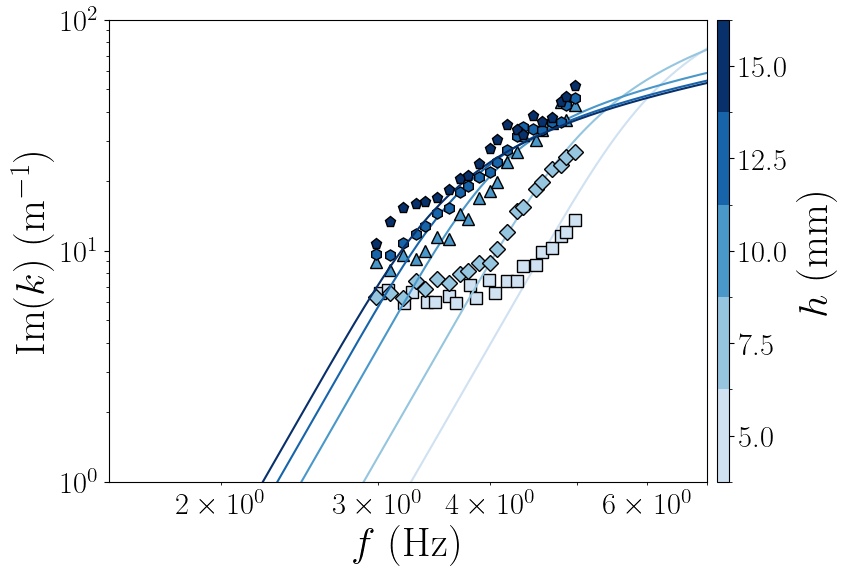

In [28]:

method = 'laser'
effective_bilayer = {}
effective_bilayer[method] = {'h':[],'nu':[],'err_nu':[]}


# physical properties
f_th = np.linspace(1e0,1e1,500)
rho_1 = 1e3 # water density
r = 1
rho_2 = rho_1/r
nu_2 = 1e-6 # water viscosity
thickness_list = [2.5,5.0,7.5,10.0,12.5,15.0] # in mm

# properties for plot
zoomed_bool = False
bounds = np.array([3.75,6.25,8.75,11.25,13.75,16.25]) # bounds used for colorbar
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256) 
marker_list = ['s','D','^','h','p'] # list of markers 
mksize = 8

set_graphs.set_matplotlib_param('double')
fig, ax = plt.subplots()

for i in range(1,len(thickness_list)):
    h_label = thickness_list[i]
    h_value = thickness_list[i]*1e-3
    
    # get experimental values
    valid_keys = []
    for key in data.keys():
        if data[key]['method'] == method and data[key]['h'] == h_label:
            valid_keys.append(key)
            
    alpha = np.array([data[key]['alpha'] for key in valid_keys])
    err_alpha = np.array([data[key]['err_alpha'] for key in valid_keys])
    f_demod = np.array([data[key]['f_demod'] for key in valid_keys])
    
    # curve_fit
    popt,pcov = scipy.optimize.curve_fit(lambda freq,nu_1 : 
                    np.imag(theory.get_wavevector_theory(freq, h_value, rho_1, rho_2, nu_1, nu_2,display = False)),
                    f_demod,alpha,p0 = 1e-3, bounds = (1e-5,1e-1))
                
    nu = popt[0]
    err_nu = np.sqrt(np.diag(pcov))[0]
    
    effective_bilayer[method]['h'].append(h_label)
    effective_bilayer[method]['nu'].append(nu)
    effective_bilayer[method]['err_nu'].append(err_nu)
    
    label_th = r'$\nu_{1} = ' + f'{nu*1e6:.1f}' + r'\, \nu_w $'
    
    # plot theory 
    current_color = new_blues(norm(h_label))
    current_marker = marker_list[i-1]
    k_th = theory.get_wavevector_theory(f_th, h_value, rho_1, rho_2, nu, nu_2,display = False)
    ax.plot(f_th,np.imag(k_th),'-',color= current_color,label = label_th)
    
    # plot experimental results
    ax.plot(f_demod,alpha,current_marker,color = current_color,markeredgecolor = 'k',
            markersize = mksize)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$f \; \mathrm{(Hz)}$')
ax.set_ylabel(r'$\mathrm{Im}(k) \; \mathrm{(m^{-1})}$')

# set colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)

sm = cm.ScalarMappable(cmap=new_blues, norm=norm)
sm.set_array([])  # Only needed for the colorbar
cbar = plt.colorbar(sm, cax=cax)
midpoints = [(bounds[i] + bounds[i+1])/2 for i in range(len(bounds) - 1)]
cbar.set_ticks(midpoints)
cbar.set_ticklabels([f'{mid:.1f}' for mid in midpoints])
cbar.set_label(r'$h \; \mathrm{(mm)}$')

# if zoomed_bool:
#     ax.set_xlim([2.7,5.3])
#     # ax.set_ylim([2e0,70])
# else:
#     ax.set_xlim([2,10])
#     ax.set_ylim([1e-2,2e2])
    
ax.set_ylim([1e0,1e2])
ax.set_xlim([1.5e0,7e0])

figname = f'{fig_folder}alpha_VS_freq_bilayer_viscous_viscous_{method}_Aurore'
plt.savefig(figname + '.pdf', bbox_inches='tight')
plt.savefig(figname + '.png', bbox_inches='tight')

# # convert list in dictionnary to array and save it
# for key in effective_bilayer[method].keys():
#     effective_bilayer[method][key] = np.array(effective_bilayer[method][key])
# rw.save_dict_to_h5(effective_bilayer,file2effective_bilayer)

## Load effective viscosity

In [25]:
fig_folder

'F:/PhD_Manuscript/ch3/Attenuation/illustration/'

In [16]:
effective = {}

file2load = 'U:/Aurore_frasil/effective_nu_Lamb.h5'
effective['Lamb'] = rw.load_dict_from_h5(file2load)

file2load = 'U:/Aurore_frasil/effective_nu_viscous_bilayer_imag.h5'
effective['bilayer'] = rw.load_dict_from_h5(file2load)

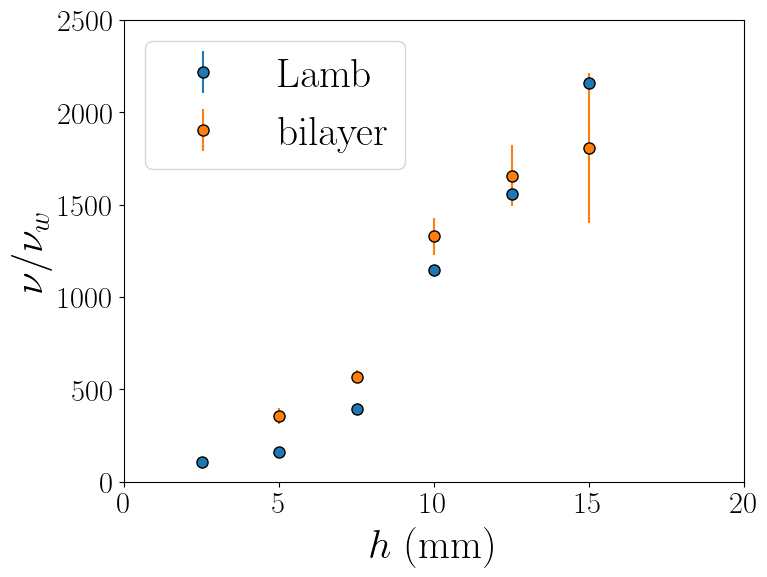

In [27]:
method = 'laser'
nu_w = 1e-6
ms = 8

set_graphs.set_matplotlib_param('double')
fig, ax = plt.subplots()

for key in effective.keys():
    x = effective[key][method]['h']
    y = effective[key][method]['nu']/nu_w
    yerr = effective[key][method]['err_nu']/nu_w

    label = key
    ax.errorbar(x,y,yerr = yerr,fmt = 'o', mec = 'k',ms = 8,label = label)


ax.set_xlim([0,20])
ax.set_ylim([0,2.5e3])
ax.legend()

ax.set_xlabel(r'$h \; \mathrm{(mm)}$')
ax.set_ylabel(r'$\nu / \nu_w$')


figname = f'{fig_folder}nu_VS_h_Lamb_bilayer_comparison_{method}_Aurore'
plt.savefig(figname + '.pdf', bbox_inches='tight')
plt.savefig(figname + '.png', bbox_inches='tight')

In [17]:
effective

{'Lamb': {'PIV': {'err_nu': array([1.79818348e-06, 8.22931048e-06, 1.15829567e-05, 1.13888392e-05,
          1.26066695e-05, 1.29642150e-05]),
   'err_prefactor': array([5.35565910e-07, 1.13323468e-06, 1.26760000e-06, 1.23837549e-06,
          1.33100945e-06, 1.35807077e-06]),
   'h': array([ 2.5,  5. ,  7.5, 10. , 12.5, 15. ]),
   'nu': array([0.00015215, 0.00071174, 0.00112696, 0.00114153, 0.0012108 ,
          0.00122993]),
   'prefactor': array([9.06327292e-05, 1.96023244e-04, 2.46661393e-04, 2.48251049e-04,
          2.55672023e-04, 2.57684208e-04])},
  'laser': {'err_nu': array([4.53232408e-07, 4.88672082e-07, 9.86117631e-07, 3.16219831e-06,
          4.58277684e-06, 5.38214837e-06]),
   'err_prefactor': array([1.60337291e-07, 1.40750804e-07, 1.81914335e-07, 3.42966945e-07,
          4.26787488e-07, 4.25508442e-07]),
   'h': array([ 2.5,  5. ,  7.5, 10. , 12.5, 15. ]),
   'nu': array([0.00010785, 0.00016269, 0.0003966 , 0.00114738, 0.00155621,
          0.00215938]),
   'prefacto